# Tutorial 2: Time-Dependent Dynamic Simulations
Welcome to the second **nanonets** tutorial!

In the first tutorial, we looked at steady-state physics using static voltages. However, real-world nanoelectronic devices often operate under high-frequency AC signals. Because nanoparticles have capacitance, they act like tiny charge reservoirs. When the voltage changes rapidly, the network needs time to charge and discharge, leading to dynamic hysteresis and transient effects.

To start, we initialize the exact same 3x3 network topology as in the previous tutorial.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nanonets

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

lattice_topology = {
    "Nx" : 3,
    "Ny" : 3,
    'e_pos': [[0, 0], [2, 2]],
    'electrode_type': 2*['constant']
}

c_s = 0.0
sim = nanonets.Simulation(topology_parameter=lattice_topology, self_cap=c_s)

## 1. Generating Dynamic AC Waveforms

To simulate a time-dependent signal, we need to create a discrete time axis and a corresponding voltage trace. We will simulate a $10 \text{ MHz}$ sinusoidal AC signal applied to the Source electrode, while keeping the Drain grounded.

Instead of manually calculating time steps and arrays, we use two convenient utility functions from ``nanonets.utils``:
- ``get_time_setup_from_frequency``: Automatically calculates the required time step (``dt``) and total number of steps based on the frequency, the number of periods, and the desired resolution (samples per period). 
- ``sinusoidal_voltages``: Generates the correctly shaped voltage matrix for our specific topology.
 
We also define an `n_plot` variable to easily slice our data later, allowing us to zoom in on the first few periods of the simulation.

In [ ]:
from nanonets.utils import get_time_setup_from_frequency, sinusoidal_voltages

# Signal Parameters
f0_hz = 60.0 * 1e6          # 10 MHz frequency
n_periods = 100             # Total number of AC cycles to simulate
samples_per_period = 40     # Time resolution per cycle
amplitude = 2.0 * 0.044    # Voltage amplitude in Volts

# Generate time vector and time step (dt)
N_steps, dt = get_time_setup_from_frequency(
    f0_hz=f0_hz, 
    n_periods=n_periods, 
    samples_per_period=samples_per_period
)

# Define a slice length for plotting later (e.g., the first 1/8th of the simulation)
n_plot = N_steps // 20

# Generate the AC voltage matrix
# Source gets the 10 MHz sine wave, Drain remains at 0.0 Hz / 0.0 V
t, x = sinusoidal_voltages(
    N_samples=N_steps, 
    topology_parameter=lattice_topology,
    amplitudes=[amplitude, 0.0], 
    frequencies=[f0_hz, 0.0], 
    time_step=dt
)

## 2. Running the Dynamic Simulation
In static KMC, every voltage point is treated as an isolated system running until it reaches an equilibrium. In dynamic KMC, time is a physical parameter. The engine tracks the absolute elapsed time as electrons jump. The voltage updates continuously in the background, forcing the system to react to the changing external potential.

To run this, we switch from ``run_static_voltages`` to ``run_dynamic_voltages``. We pass the time array ``t`` (or individual time steps) alongside the voltage matrix ``x``. Since time is now strictly correlated across steps, we only rely on the ensemble average over multiple parallel trajectories (``n_traj``) rather than defining "equilibration jumps".

In [3]:
# Number of parallel trajectories for the ensemble average
n_traj = 1000

# Run the dynamic KMC simulation
sim.run_dynamic_voltages(
    voltages=x, 
    time_steps=t, 
    target_electrode=1, 
    n_trajectories=n_traj,
    T_val=0.1
)

## 3. Visualizing Dynamic Hysteresis and Currents

When analyzing AC-driven nanoelectronic devices, we usually look at the data from two different perspectives:

1. Time Domain (Top Row): This shows how the currents evolve over time as the AC voltage oscillates. We can clearly observe the phase shift between the discrete tunneling events ($I_{KMC}$) and the continuous capacitive charging ($I_{disp}$).
2. Voltage Domain / Phase Space (Bottom Row): By plotting the currents against the instantaneous applied voltage (instead of time), we reveal the dynamic hysteresis loops of the device. These loops indicate memory effects and energy dissipation within the nanoparticle network.

Let's visualize the three current components ($I_{KMC}$, $I_{disp}$, and $I_{Total}$) in both domains. We will use ``sim.get_observable_displacement_storage()`` which we automatically computed in the background during the ``run_dynamic_voltages`` call.

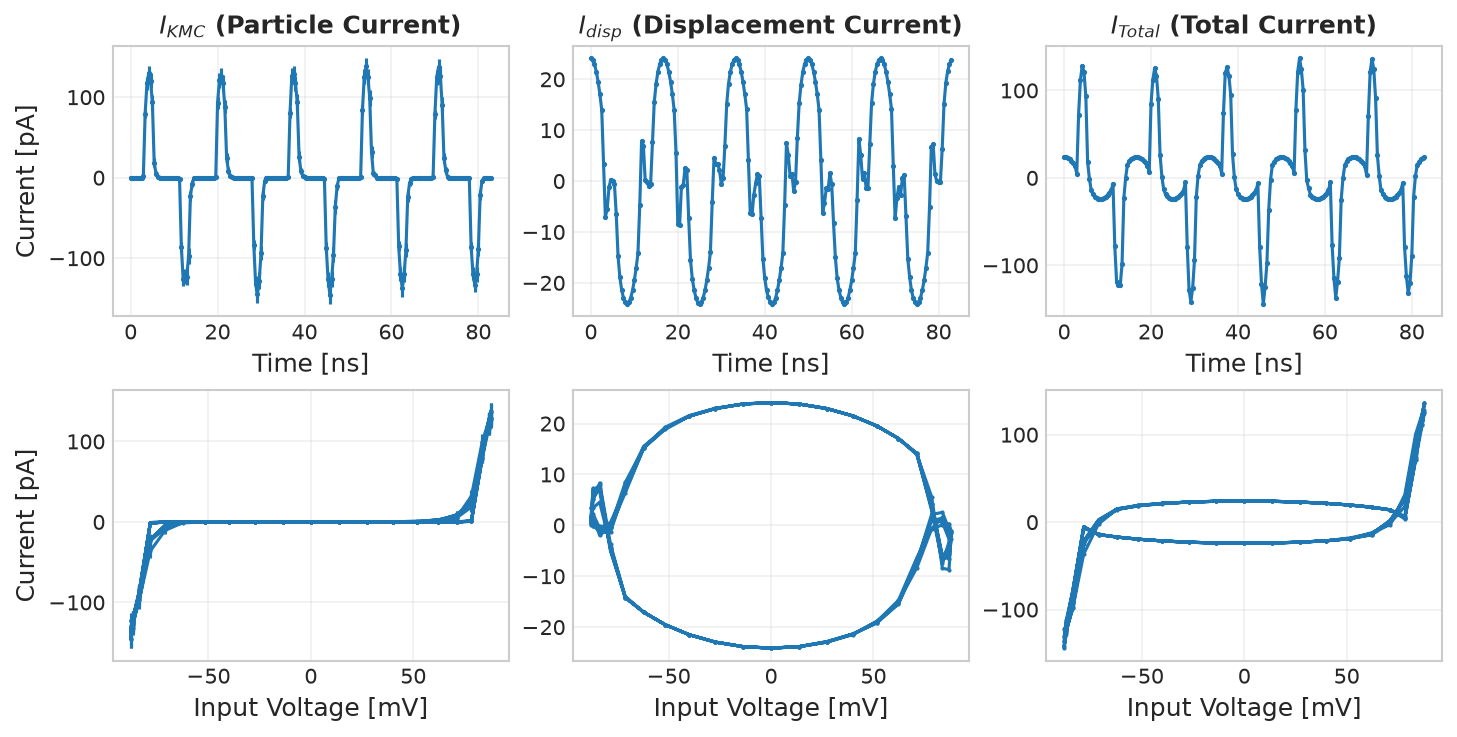

In [12]:
# 1. Extract and scale data
V_plot = x[:n_plot, 0] * 1e3  # Convert Voltage to mV
t_plot = t[:n_plot] * 1e9     # Convert Time to ns

# Define scaling factor for the currents to reach picoamperes (pA)
scale_I = 1e-6 
I_kmc = sim.get_observable_storage() * scale_I
I_kmc_err = sim.get_observable_error_storage() * scale_I
I_disp = sim.get_observable_displacement_storage() * scale_I
I_total = I_kmc + I_disp

# 2. Setup a 2x3 grid figure
fig, axes = plt.subplots(2, 3, dpi=150, layout='constrained')
fig.set_figwidth(fig.get_figwidth()*1.5)

# ==========================================
# --- TOP ROW: TIME DOMAIN ---
# ==========================================

# 1. KMC Current
axes[0, 0].errorbar(t_plot, I_kmc[:n_plot], yerr=I_kmc_err[:n_plot], fmt='.-', markersize=3)
axes[0, 0].set_title('$I_{KMC}$ (Particle Current)', size='large', weight='bold')
axes[0, 0].set_ylabel("Current [pA]", size='large')

# 2. Displacement Current
axes[0, 1].plot(t_plot, I_disp[:n_plot], '.-', markersize=3)
axes[0, 1].set_title('$I_{disp}$ (Displacement Current)', size='large', weight='bold')

# 3. Total Current
axes[0, 2].plot(t_plot, I_total[:n_plot], '.-', markersize=3)
axes[0, 2].set_title('$I_{Total}$ (Total Current)', size='large', weight='bold')

for ax in axes[0, :]:
    ax.set_xlabel("Time [ns]", size='large')
    ax.grid(True, alpha=0.3)


# ==========================================
# --- BOTTOM ROW: VOLTAGE DOMAIN (HYSTERESIS) ---
# ==========================================

# 1. KMC Current Hysteresis
axes[1, 0].errorbar(V_plot, I_kmc[:n_plot], yerr=I_kmc_err[:n_plot], fmt='.-', markersize=2)
axes[1, 0].set_ylabel("Current [pA]", size='large')

# 2. Displacement Current Hysteresis
axes[1, 1].plot(V_plot, I_disp[:n_plot], '.-', markersize=2)

# 3. Total Current Hysteresis
axes[1, 2].plot(V_plot, I_total[:n_plot], '.-', markersize=2)

for ax in axes[1, :]:
    ax.set_xlabel("Input Voltage [mV]", size='large')
    ax.grid(True, alpha=0.3)

## 4. Frequency Domain Analysis and Harmonic Features

While time-domain plots beautifully visualize the dynamic hysteresis and phase shifts, the complex nonlinear behaviors (like the step-like Coulomb blockades) are often better analyzed in the frequency domain. 

In this section, we analyze the steady-state AC response. We first discard the initial transient phase where the system settles into its dynamic equilibrium. 

We then use the custom `extract_harmonic_features` and `get_frequency_spectrum` functions from our `nanonets.utils.signals` module. The `extract_harmonic_features` function is particularly powerful: it uses Blackman windowing and parabolic interpolation to extract the exact amplitudes of specific harmonic orders with high precision. We can use these extracted peaks to calculate the **Total Harmonic Distortion (THD)**, a key metric for quantifying the nonlinearity of our nanoparticle network.

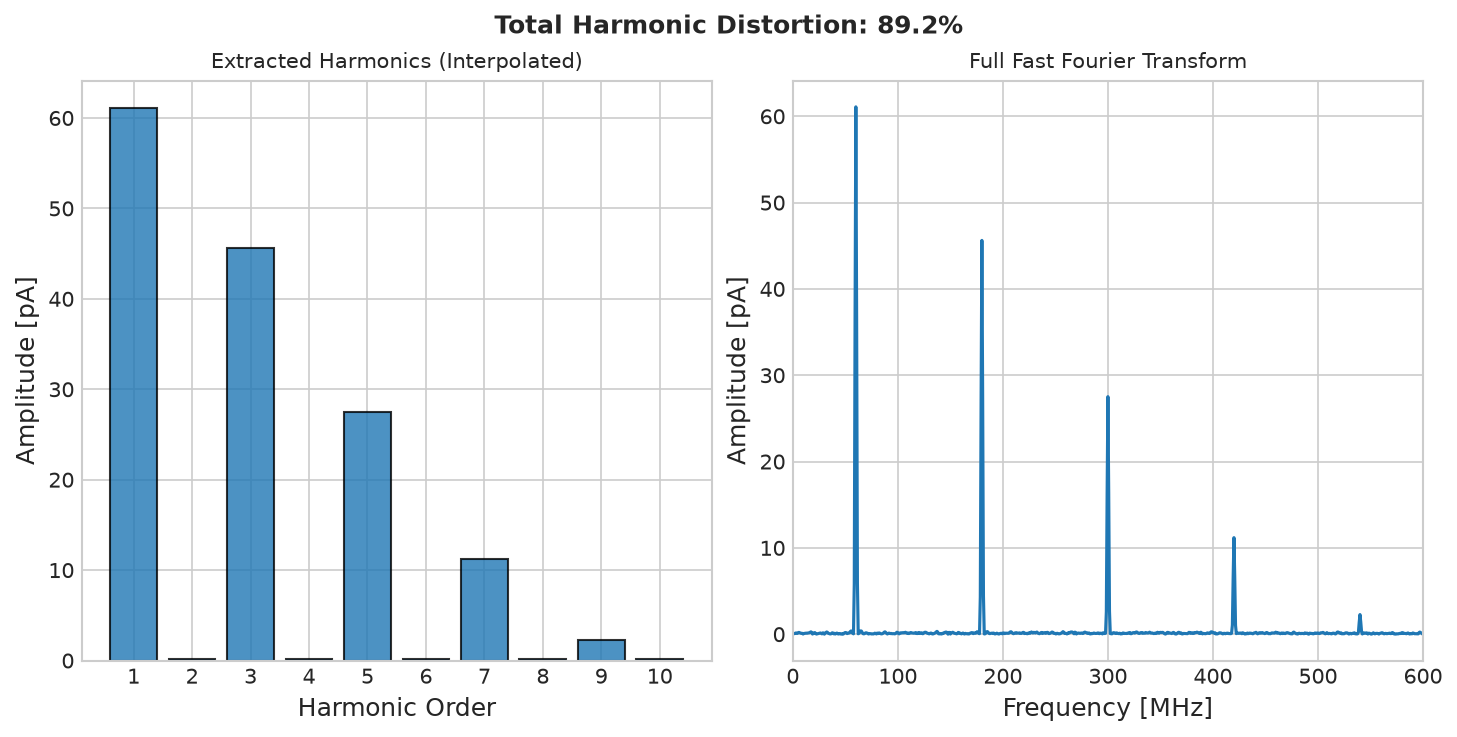

In [69]:
from nanonets.utils.signals import compute_thd, extract_harmonic_features, get_frequency_spectrum

# 1. Isolate the Steady-State Signal
# We discard the first 20 periods to avoid transient charging artifacts
eq_periods = 20
steady_state_I = I_total[eq_periods * samples_per_period:]
steady_periods_count = n_periods - eq_periods

# 2. Extract specific harmonic peaks using parabolic interpolation
harmonic_i = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
features = extract_harmonic_features(
    y_val=steady_state_I, 
    n_vals=harmonic_i, 
    N_periods=steady_periods_count, 
    mode='abs'
)

# Calculate Total Harmonic Distortion from the extracted features
thd_value = compute_thd(features)

# 3. Calculate the full continuous spectrum for visual comparison
freqs, amplitudes = get_frequency_spectrum(signal=steady_state_I, dt=dt)

# --- PLOTTING ---
fig = plt.figure(dpi=150, layout='constrained')
fig.set_figwidth(fig.get_figwidth() * 1.5) # Widen the figure for the side-by-side layout

# Left Subplot: Extracted Harmonic Bar Chart
ax1 = fig.add_subplot(1, 2, 1)
# Scale the extracted amplitudes to pA for readability
ax1.bar(x=harmonic_i, height=features, edgecolor='black', alpha=0.8)
ax1.set_xticks(harmonic_i)
ax1.set_xlabel('Harmonic Order', size='large')
ax1.set_ylabel('Amplitude [pA]', size='large')
ax1.set_title("Extracted Harmonics (Interpolated)", size='medium')

# Right Subplot: Full Frequency Spectrum
ax2 = fig.add_subplot(1, 2, 2)
# Convert frequencies to MHz
ax2.plot(freqs * 1e-6, amplitudes)
ax2.set_xlim(0, 10 * f0_hz * 1e-6) # Limit view to the first 10 harmonics
ax2.set_xlabel('Frequency [MHz]', size='large')
ax2.set_ylabel('Amplitude [pA]', size='large')
ax2.set_title("Full Fast Fourier Transform", size='medium')

fig.suptitle(f"Total Harmonic Distortion: {thd_value*100:.1f}%", size='large', weight='bold')
plt.show()